# Interpret SAE features
[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/rotskoff-group/idiom/blob/v1/cookbook/notebooks/interpret_sae_features.ipynb)

Encode IDRs, rank active features, and inspect their residue traces and peak-centered sequence windows.


## Setup
A GPU runtime is recommended: **Runtime → Change runtime type → GPU**. CPU execution is supported but slower.

Run cells in order. Installation is self-contained; no repository clone or account is needed. If Colab requests a session restart after installation, restart before running the imports. The first model load downloads weights.


In [ ]:
import sys

!"{sys.executable}" -m pip install -q "idiom @ git+https://github.com/rotskoff-group/idiom.git@v1"

In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from idiom import IDiomSAE
from idiom.utils.notebook_helpers import check_context, example_file, load_inputs, save_run, summaries

started = time.perf_counter()

## Settings
Upload a FASTA through Colab’s Files pane, or use the example. Annotated protein headers use `_IDR_start-end` with 1-based, inclusive coordinates.


In [2]:
INPUT_FASTA = None # Default: ProtGPS nucleolus IDRs; otherwise set a FASTA path
INPUT_MODE = "idr" # "idr" for isolated IDRs; "annotated" for full proteins with IDR spans
MAX_RECORDS = 16 # Maximum accepted records; None uses all
SAE_ID = "jxliu2/idiomsae-300M-L18-k32" # Pretrained SAE and its frozen host model
DEVICE = "auto" # "cpu" or "cuda"; "auto" uses an available GPU
BATCH_SIZE = 2 # Sequences per SAE encoding batch
FEATURE_IDS = None # None selects the strongest active feature; or use a list of IDs
OUT_DIR = Path("inspection_outputs") / time.strftime("%Y%m%d-%H%M%S") # New timestamped folder per run

## Encode and rank
The SAE uses its frozen host model. Rankings describe activation in this input set.


In [3]:
from idiom.sae.features import AMINO_ACIDS, FeatureDataset, logo_data

OUT_DIR.mkdir(parents=True, exist_ok=True)
input_path = INPUT_FASTA or example_file("protgps/nucleolus.fasta", Path("example_inputs"))
records, audit = load_inputs(input_path, INPUT_MODE, MAX_RECORDS)
audit.to_csv(OUT_DIR / "input_audit.csv", index=False)
print("Input audit:", audit.status.value_counts().to_dict())
if not records:
    raise ValueError("No accepted sequences; review the audit.")
sae = IDiomSAE.from_pretrained(SAE_ID, device=DEVICE)
check_context(records, sae.model.cfg.max_seq_len, include_flanks=sae.fim_mode == "prompted")
feature_dir = sae.build_feature_dataset(records, OUT_DIR / "features", batch_size=BATCH_SIZE)
index = summaries(records, audit)
index.insert(0, "dataset_sequence", range(len(records)))
index.to_csv(OUT_DIR / "sequence_index.csv", index=False)
dataset = FeatureDataset(feature_dir)
maximum, total, count = dataset.feature_ranking()
ranking = pd.DataFrame(
    dict(feature_id=range(dataset.num_latents), maximum=maximum, total=total, firing_residues=count)
)
ranking = ranking.sort_values("maximum", ascending=False, kind="stable")
ranking.to_csv(OUT_DIR / "feature_ranking.csv", index=False)
feature_ids = (
    ranking.loc[ranking.maximum > 0, "feature_id"].head(1).tolist() if FEATURE_IDS is None else FEATURE_IDS
)
display(ranking.head(3))

if not feature_ids:
    print("No active features found in these inputs.")

Input audit: {'outside sample limit': 134, 'accepted': 16}


,feature_id,maximum,total,firing_residues
10548,10548,383.082245,1681.119263,20
13629,13629,363.258972,2004.229126,16
7014,7014,348.816376,13160.812500,147


## Inspect residue activations
For each feature, show the sequence with its strongest activation. Positions index the stored FIM string, excluding START. Marker positions are not residue rows.


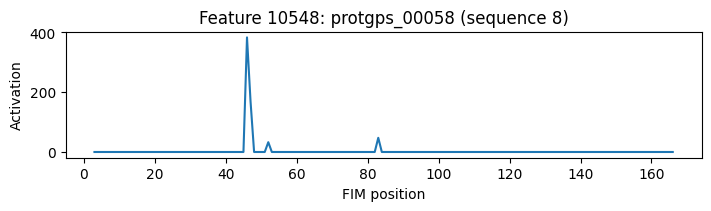

In [4]:
for feature in feature_ids:
    sequence_ids, _ = dataset.top_sequences(feature, n=1)
    if not len(sequence_ids):
        print(f"Feature {feature} does not fire in these inputs.")
        continue
    sequence_id = int(sequence_ids[0])
    accession = index.iloc[sequence_id].accession
    positions, values = dataset.trace(sequence_id, feature)
    fig, ax = plt.subplots(figsize=(7, 2), constrained_layout=True)
    ax.plot(positions, values)
    ax.set(
        title=f"Feature {feature}: {accession} (sequence {sequence_id})",
        xlabel="FIM position",
        ylabel="Activation",
    )
    fig.savefig(OUT_DIR / f"feature_{feature}_trace.png", dpi=150)
    plt.show()

## Inspect sequence windows
One window per sequence, centered on its strongest activation. Missing edge residues stay aligned. Letter heights measure information relative to a uniform amino-acid background.


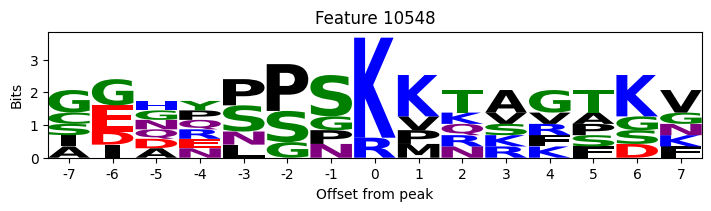

,sequence_id,peak_position,residues
0,8,46,CDGQNPPKKQAGSKF
1,15,19,GEDYPSGKKRAGTDG
2,13,293,SINNSSSKPTKVAKV


In [5]:
import logomaker

for feature in feature_ids:
    data = logo_data(dataset, feature, n=20, half_width=7)
    if not data["windows"]:
        continue
    fig, ax = plt.subplots(figsize=(7, 2), constrained_layout=True)
    logomaker.Logo(
        pd.DataFrame(data["information"], columns=list(AMINO_ACIDS)),
        ax=ax,
        color_scheme="chemistry",
    )
    ax.set_ylim(0, max(1.0, float(data["information"].sum(axis=1).max()) * 1.05))
    ax.set_xticks(range(len(data["offsets"])), data["offsets"])
    ax.set(title=f"Feature {feature}", xlabel="Offset from peak", ylabel="Bits")
    fig.savefig(OUT_DIR / f"feature_{feature}_logo.png", dpi=150)
    plt.show()
    windows = pd.DataFrame([vars(w) for w in data["windows"]])
    display(windows[["sequence_id", "peak_position", "residues"]].head(3))
    windows.to_csv(OUT_DIR / f"feature_{feature}_windows.csv", index=False)

## Results
`feature_ranking.csv` ranks the SAE features. `sequence_index.csv` maps dataset indices to input accessions. The `features/` directory holds encoded activations; the PNG and window CSV files show the inspected features.

`run.json` records the settings and package versions. Open the output folder in Colab’s **Files** pane to download results. Download them before the runtime ends, or copy them to mounted Drive. Saved notebook previews do not include the exported files.


Saved previews show a CPU example run. Run the cells to create the exported files.

In [6]:
save_run(
    OUT_DIR,
    dict(
        sae=SAE_ID,
        device=DEVICE,
        input=str(input_path),
        input_mode=INPUT_MODE,
        max_records=MAX_RECORDS,
        features=feature_ids,
    ),
    elapsed=time.perf_counter() - started,
)
print("Results folder:", OUT_DIR)

Results folder: inspection_outputs/20260921-134438
